#  Lab Session 9 & 10: attention, transformers and fine-tuning of LLMs

- **Lab Session 9**: the attention mechanism
- **Lab Session 10**: loading and fine-tuning models
📅 _Based on Hugging Face Notebook and Data Science Summer School 2023, 22.08.2023_

👨‍🏫 All credits to [Steven Liu](https://huggingface.co/stevhliu) & the Hugging Face community.

##Attention


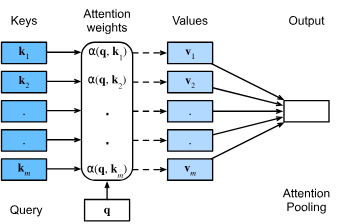

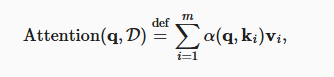

Source: [Book dl2ai](https://d2l.ai/chapter_attention-mechanisms-and-transformers/index.html)

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k):
        super(ScaledDotProductAttention, self).__init__()
        self.scaling_factor = torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

    def forward(self, Q, K, V):
        # Compute attention scores
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scaling_factor
        attention_weights = torch.softmax(attention_scores, dim=-1)

        # Apply attention weights to the values
        output = torch.matmul(attention_weights, V)

        return output, attention_weights

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadSelfAttention, self).__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.d_v = d_model // num_heads

        # Define linear layers for Q, K, V
        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.fc_out = nn.Linear(d_model, d_model)

        # Attention layer
        self.attention = ScaledDotProductAttention(self.d_k)

    def forward(self, x):
        batch_size = x.size(0)

        # Linear projections for each head
        Q = self.q_linear(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.k_linear(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.v_linear(x).view(batch_size, -1, self.num_heads, self.d_v).transpose(1, 2)

        # Apply attention to each head
        attn_outputs, attn_weights = self.attention(Q, K, V)

        # Concatenate attention output for all heads
        attn_outputs = attn_outputs.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        # Final linear layer
        output = self.fc_out(attn_outputs)
        return output, attn_weights




In [ ]:
import torch.nn.functional as F

vocab = [
    "Apple", "Bridge", "Canvas", "Drift", "Ember", "Falcon", "Glimmer", "Harbor",
    "Indigo", "Jasper", "Kettle", "Lantern", "Meadow", "Nimbus", "Orbit", "Prism",
    "Quartz", "Ripple", "Sunset", "Timber", "Unity", "Valley", "Wander", "Xylophone",
    "Yearn", "Zephyr", "Anchor", "Blossom", "Cascade", "Dream", "Echo", "Feather",
    "Grove", "Horizon", "Illusion", "Journey", "Kingdom", "Luminous", "Mirage", "Nestle",
    "Oasis", "Petal", "Quiver", "Radiant", "Solace", "Twilight", "Umbra", "Voyage",
    "Whisper", "Yield", "Zenith", "Xena", "Breeze", "Cradle", "Driftwood", "Emberglow",
    "Frost", "Glisten", "Haven", "Infinity", "Tame", "Kinetic", "Lucid", "Mosaic"
]

def random_word_sequences(words, p=0.5, seq_len=10):
  first_word, = np.random.choice(words, size=1)
  words = [w for w in words if w!=first_word]
  freq = sum([1 for w in words if w[0] == first_word[0]])
  p_same_initial = p / freq
  p_diff_initial = (1-p) / (len(words)-freq)
  p = [p_same_initial*(w[0] == first_word[0]) +
       p_diff_initial*(1- (w[0] == first_word[0]))
       for w in words]
  next_words = np.random.choice(words, size=seq_len - 1, p=p)
  return [first_word] + list(next_words)

def encode_word_sequence(sequence, vocab):
  one_hot = [F.one_hot(torch.tensor(vocab.index(w)), num_classes=len(vocab)) for w in sequence]
  one_hot = torch.stack(one_hot)
  one_hot = one_hot.to(torch.float)
  return one_hot

def plot_weights(attn_weights):
  # Plot the attention weights
  attn_weights = attn_weights.detach().numpy()
  fig, ax = plt.subplots()
  sns.heatmap(attn_weights, ax=ax,cmap="viridis")
  fig.suptitle("Attention Weights for Head 1")
  ax.set_xlabel("Key Position")
  ax.set_ylabel("Query Position")

  return fig

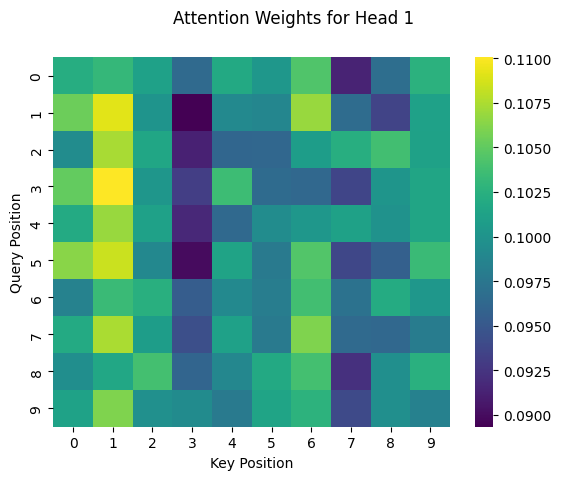

In [ ]:
#Given a set of words and a Markov probability matrix, create vecto

# Set up parameters
d_model = 64  # Dimension of the model (vocab size)
num_heads = 4  # Number of attention heads
seq_len = 10  # Length of the input sequence

# Create a random input tensor
x = torch.rand(1, seq_len, d_model)  # (batch_size, sequence_length, d_model)

# Initialize the multi-head self-attention layer
model = MultiHeadSelfAttention(d_model, num_heads)
# Forward pass through the multi-head self-attention layer
output, attn_weights = model(x)
_ = plot_weights(attn_weights[0,0])



Text(0.5, 1.0, 'Value')

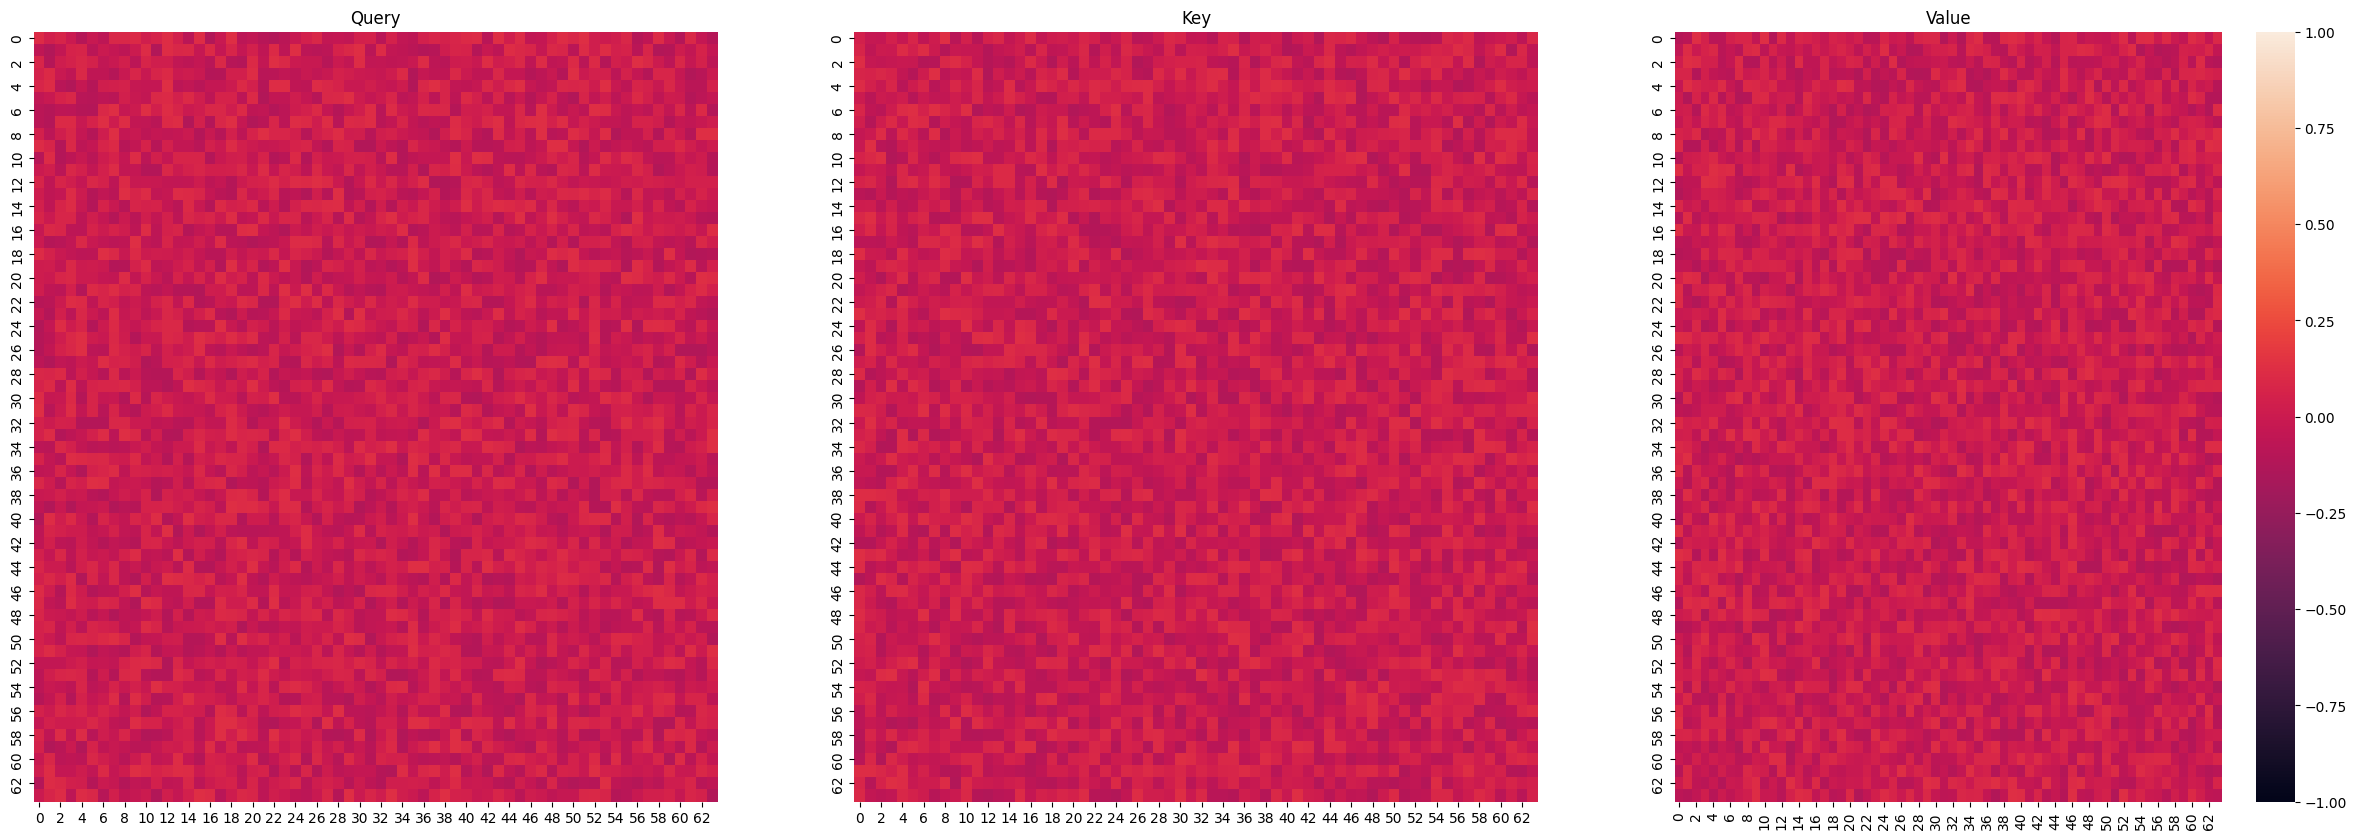

In [ ]:
fig, (ax0,ax1,ax2) = plt.subplots(1,3, figsize=(30,10))

sns.heatmap(model.q_linear.weight.detach().numpy(), ax=ax0, vmin=-1, vmax=1, cbar=False)
sns.heatmap(model.k_linear.weight.detach().numpy(), ax=ax1, vmin=-1, vmax=1, cbar=False)
sns.heatmap(model.v_linear.weight.detach().numpy(), ax=ax2, vmin=-1, vmax=1, cbar=True)
ax0.set_title('Query')
ax1.set_title('Key')
ax2.set_title('Value')

100%|██████████| 10000/10000 [00:28<00:00, 353.88it/s]


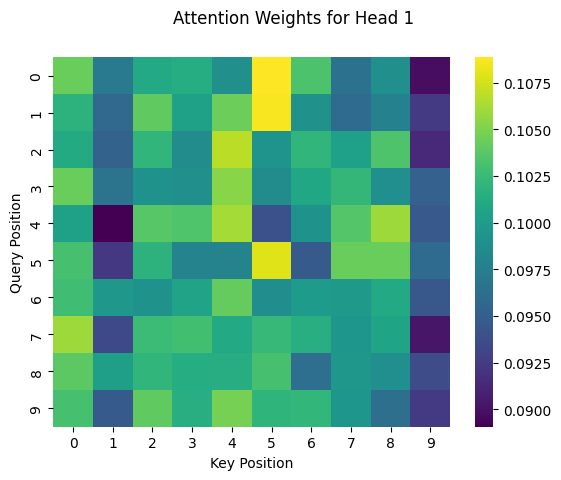

In [ ]:
from tqdm import tqdm


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters())

for iter in tqdm(range(10**4)):
  optimizer.zero_grad()
  seq = encode_word_sequence(random_word_sequences(vocab, p=0.9), vocab)
  X, y = seq[None,:1, :], seq[None, [0], :]
  out, _ = model(X)

  loss = criterion(out, y)
  loss.backward()
  optimizer.step()

_ = plot_weights(attn_weights[0,0])


##Activate a GPU running time and install packages
In order to run this notebook on a GPU, click on "Runtime" > "Change runtime type" > select "GPU" in the menu bar in to top left. Training a Transformer is much faster on a GPU. Given Colabs's usage limits for GPUs, it is advisable to first test your non-training code on a CPU and only use the GPU once you know that everything is working.

In [ ]:
# Transformers installation
!pip install transformers==4.23 datasets evaluate rouge_score accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 19.1 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=ffc4e83afa5e09a80d9866442e63fe21347e1e3e4990a60182648e05a0e74b33
  Stored in directory: /root/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28

In [ ]:
# info on the GPU you are using
!nvidia-smi
# info on available ram
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('\n\nYour runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

Mon Nov 13 07:40:02 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   42C    P8     9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

## Generative tasks
Text generation is an important component to many NLP tasks, such as open-ended text generation, summarization, translation and mixed-modality applications such as speech-to-text and vision-to-text translation. For this tutorial, we will focus on summarization.


Summarization creates a shorter version of a document or an article that captures all the important information. It can be formulated as a sequence-to-sequence task and be:

- Extractive: extract the most relevant information from a document.
- Abstractive: generate new text that captures the most relevant information.

This guide will show you how to:

1. Finetune [T5](https://huggingface.co/t5-small) on the California state bill subset of the [BillSum](https://huggingface.co/datasets/billsum) dataset for abstractive summarization.
2. Use your finetuned model for inference.

The task illustrated in this tutorial is supported by the following model architectures:

[BART](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/bart), [BigBird-Pegasus](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/bigbird_pegasus), [Blenderbot](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/blenderbot), [BlenderbotSmall](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/blenderbot-small), [Encoder decoder](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/encoder-decoder), [FairSeq Machine-Translation](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/fsmt), [GPTSAN-japanese](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/gptsan-japanese), [LED](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/led), [LongT5](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/longt5), [M2M100](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/m2m_100), [Marian](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/marian), [mBART](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/mbart), [MT5](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/mt5), [MVP](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/mvp), [NLLB](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/nllb), [NLLB-MOE](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/nllb-moe), [Pegasus](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/pegasus), [PEGASUS-X](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/pegasus_x), [PLBart](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/plbart), [ProphetNet](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/prophetnet), [SwitchTransformers](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/switch_transformers), [T5](https://huggingface.co/docs/transformers/main/en/tasks/../model_doc/t5), [XLM-ProphetNet](https://huggingface.co/docs/transformers/main/en/tasks/../##model_doc/xlm-prophetnet)


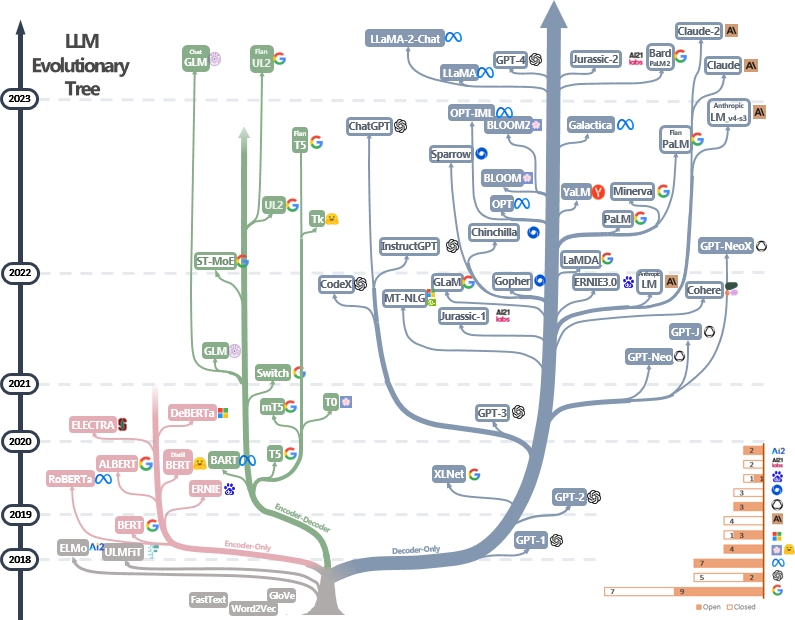

In [ ]:
import requests
from IPython.display import display
from PIL import Image as PILImage
from io import BytesIO

# source: https://github.com/Mooler0410/LLMsPracticalGuide/tree/main
image_url = 'https://github.com/Mooler0410/LLMsPracticalGuide/blob/main/imgs/tree.jpg?raw=true'
response = requests.get(image_url)
img = PILImage.open(BytesIO(response.content))

display(img)

## Load BillSum dataset

Start by loading the smaller California state bill subset of the BillSum dataset from the 🤗 Datasets library:

In [ ]:
from datasets import load_dataset

billsum = load_dataset("billsum", split="ca_test")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.27k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/91.8M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/15.8M [00:00<?, ?B/s]

ca_test-00000-of-00001.parquet:   0%|          | 0.00/6.12M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18949 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3269 [00:00<?, ? examples/s]

Generating ca_test split:   0%|          | 0/1237 [00:00<?, ? examples/s]

Split the dataset into a train and test set with the [train_test_split](https://huggingface.co/docs/datasets/main/en/package_reference/main_classes#datasets.Dataset.train_test_split) method:

In [ ]:
billsum = billsum.train_test_split(test_size=0.2)

Then take a look at an example:

In [ ]:
billsum["train"][0]

{'text': 'The people of the State of California do enact as follows:\n\n\nSECTION 1.\nSection 19227 of the Food and Agricultural Code is amended to read:\n19227.\n(a) In addition to the license fee required pursuant to Section 19225, the department may charge each licensed renderer and collection center an additional fee necessary to cover the reasonable costs of administering Article 6 (commencing with Section 19300) and Article 6.5 (commencing with Section 19310). The additional fees authorized to be imposed by this section may not exceed ten thousand dollars ($10,000) per year per each licensed rendering plant or collection center.\n(b) The secretary may, based upon the findings and recommendation of the Rendering Industry Advisory Board, determine the additional fee amounts necessary to provide the revenue needed to carry out the provisions of this chapter specified in subdivision (a). The secretary and the Rendering Industry Advisory Board shall not exceed the maximum amount for a

There are two fields that you'll want to use:

- `text`: the text of the bill which'll be the input to the model.
- `summary`: a condensed version of `text` which'll be the model target.

## Preprocess

The next step is to load a T5 tokenizer to process `text` and `summary`:

In [ ]:
from transformers import AutoTokenizer

checkpoint = "t5-small"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


Moving 0 files to the new cache system


0it [00:00, ?it/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

The preprocessing function you want to create needs to:

1. Prefix the input with a prompt so T5 knows this is a summarization task. Some models capable of multiple NLP tasks require prompting for specific tasks.
2. Use the keyword `text_target` argument when tokenizing labels.
3. Truncate sequences to be no longer than the maximum length set by the `max_length` parameter.

In [ ]:
prefix = "summarize: "


def preprocess_function(examples):
    inputs = [prefix + doc for doc in examples["text"]]
    model_inputs = tokenizer(inputs, max_length=1024, truncation=True)

    labels = tokenizer(text_target=examples["summary"], max_length=128, truncation=True)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

To apply the preprocessing function over the entire dataset, use 🤗 Datasets [map](https://huggingface.co/docs/datasets/main/en/package_reference/main_classes#datasets.Dataset.map) method. You can speed up the `map` function by setting `batched=True` to process multiple elements of the dataset at once:

In [ ]:
tokenized_billsum = billsum.map(preprocess_function, batched=True)

Map:   0%|          | 0/989 [00:00<?, ? examples/s]

Map:   0%|          | 0/248 [00:00<?, ? examples/s]

Now create a batch of examples using [DataCollatorForSeq2Seq](https://huggingface.co/docs/transformers/main/en/main_classes/data_collator#transformers.DataCollatorForSeq2Seq). It's more efficient to *dynamically pad* the sentences to the longest length in a batch during collation, instead of padding the whole dataset to the maximum length.

In [ ]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=checkpoint)

## Evaluate

Including a metric during training is often helpful for evaluating your model's performance. You can quickly load a evaluation method with the 🤗 [Evaluate](https://huggingface.co/docs/evaluate/index) library. For this task, load the [ROUGE](https://huggingface.co/spaces/evaluate-metric/rouge) metric (see the 🤗 Evaluate [quick tour](https://huggingface.co/docs/evaluate/a_quick_tour) to learn more about how to load and compute a metric):

In [ ]:
import evaluate

rouge = evaluate.load("rouge")

Then create a function that passes your predictions and labels to [compute](https://huggingface.co/docs/evaluate/main/en/package_reference/main_classes#evaluate.EvaluationModule.compute) to calculate the ROUGE metric:

In [ ]:
import numpy as np


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)

    prediction_lens = [np.count_nonzero(pred != tokenizer.pad_token_id) for pred in predictions]
    result["gen_len"] = np.mean(prediction_lens)

    return {k: round(v, 4) for k, v in result.items()}

Your `compute_metrics` function is ready to go now, and you'll return to it when you setup your training.

## Train

<Tip>

If you aren't familiar with finetuning a model with the [Trainer](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer), take a look at the basic tutorial [here](https://huggingface.co/docs/transformers/main/en/tasks/../training#train-with-pytorch-trainer)!

</Tip>

You're ready to start training your model now! Load T5 with [AutoModelForSeq2SeqLM](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoModelForSeq2SeqLM):

In [ ]:
from transformers import AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer

model = AutoModelForSeq2SeqLM.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

At this point, only three steps remain:

1. Define your training hyperparameters in [Seq2SeqTrainingArguments](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Seq2SeqTrainingArguments). The only required parameter is `output_dir` which specifies where to save your model. You'll push this model to the Hub by setting `push_to_hub=True` (you need to be signed in to Hugging Face to upload your model). At the end of each epoch, the [Trainer](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer) will evaluate the ROUGE metric and save the training checkpoint.
2. Pass the training arguments to [Seq2SeqTrainer](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Seq2SeqTrainer) along with the model, dataset, tokenizer, data collator, and `compute_metrics` function.
3. Call [train()](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train) to finetune your model.

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir="my_model",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    #per_device_train_batch_size=16,
    #per_device_eval_batch_size=16,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=4,
    predict_with_generate=True,
    fp16=True,
    #push_to_hub=True,
)


trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_billsum["train"],
    eval_dataset=tokenized_billsum["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Using cuda_amp half precision backend
The following columns in the training set don't have a corresponding argument in `T5ForConditionalGeneration.forward` and have been ignored: summary, title, text. If summary, title, text are not expected by `T5ForConditionalGeneration.forward`,  you can safely ignore this message.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
***** Running training *****
  Num examples = 989
  Num Epochs = 4
  Instantaneous batch size per device = 8
  Total train batch size (w. parallel, distributed & accumulation) = 8
  Gradient Accumulation steps = 1
  Total optimization steps = 496
You're using a T5TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,No log,2.664473,0.135000,0.043800,0.111600,0.111700,19.000000
2,No log,2.525541,0.144300,0.054100,0.120300,0.120700,19.000000
3,No log,2.479613,0.167500,0.072300,0.140300,0.140600,19.000000
4,No log,2.466175,0.176700,0.079400,0.149400,0.149800,19.000000


The following columns in the evaluation set don't have a corresponding argument in `T5ForConditionalGeneration.forward` and have been ignored: summary, title, text. If summary, title, text are not expected by `T5ForConditionalGeneration.forward`,  you can safely ignore this message.
***** Running Evaluation *****
  Num examples = 248
  Batch size = 8
The following columns in the evaluation set don't have a corresponding argument in `T5ForConditionalGeneration.forward` and have been ignored: summary, title, text. If summary, title, text are not expected by `T5ForConditionalGeneration.forward`,  you can safely ignore this message.
***** Running Evaluation *****
  Num examples = 248
  Batch size = 8
The following columns in the evaluation set don't have a corresponding argument in `T5ForConditionalGeneration.forward` and have been ignored: summary, title, text. If summary, title, text are not expected by `T5ForConditionalGeneration.forward`,  you can safely ignore this message.
***** Runn

TrainOutput(global_step=496, training_loss=2.8357115714780745, metrics={'train_runtime': 301.7304, 'train_samples_per_second': 13.111, 'train_steps_per_second': 1.644, 'total_flos': 1070824333246464.0, 'train_loss': 2.8357115714780745, 'epoch': 4.0})

<Tip>

For a more in-depth example of how to finetune a model for summarization, take a look at the corresponding
[notebook](https://colab.research.google.com/github/huggingface/notebooks/blob/main/examples/summarization.ipynb).

</Tip>

## Inference

Great, now that you've finetuned a model, you can use it for inference!

Come up with some text you'd like to summarize. For T5, you need to prefix your input depending on the task you're working on. For summarization you should prefix your input as shown below:

In [ ]:
text = "summarize: The Inflation Reduction Act lowers prescription drug costs, health care costs, and energy costs. It's the most aggressive action on tackling the climate crisis in American history, which will lift up American workers and create good-paying, union jobs across the country. It'll lower the deficit and ask the ultra-wealthy and corporations to pay their fair share. And no one making under $400,000 per year will pay a penny more in taxes."

The simplest way to try out your finetuned model for inference is to use it in a [pipeline()](https://huggingface.co/docs/transformers/main/en/main_classes/pipelines#transformers.pipeline). Instantiate a `pipeline` for summarization with your model, and pass your text to it:

In [ ]:
from transformers import pipeline

summarizer = pipeline("summarization", model="stevhliu/my_awesome_billsum_model")
#summarizer = pipeline("summarization", model=model)
summarizer(text)

RuntimeError: Failed to import transformers.models.t5.modeling_tf_t5 because of the following error (look up to see its traceback):
No module named 'keras.saving.hdf5_format'

You can also manually replicate the results of the `pipeline` if you'd like:


Tokenize the text and return the `input_ids` as PyTorch tensors:

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("stevhliu/my_awesome_billsum_model")
inputs = tokenizer(text, return_tensors="pt").input_ids

tokenizer_config.json:   0%|          | 0.00/2.35k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

Use the [generate()](https://huggingface.co/docs/transformers/main/en/main_classes/text_generation#transformers.GenerationMixin.generate) method to create the summarization. For more details about the different text generation strategies and parameters for controlling generation, check out the [Text Generation](https://huggingface.co/docs/transformers/main/en/tasks/../main_classes/text_generation) API.

In [ ]:
from transformers import AutoModelForSeq2SeqLM

model = AutoModelForSeq2SeqLM.from_pretrained("stevhliu/my_awesome_billsum_model")
outputs = model.generate(inputs, max_new_tokens=100, do_sample=False)

pytorch_model.bin:   0%|          | 0.00/242M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/modeling_utils.py:399: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(checkpoint_file, map_location="cp

Decode the generated token ids back into text:

In [ ]:
tokenizer.decode(outputs[0], skip_special_tokens=True)

"The Inflation Reduction Act lowers prescription drug costs, health care costs, and energy costs. It's the most aggressive action on tackling the climate crisis in American history. It'll ask the ultra-wealthy and corporations to pay their fair share."

# More resources



In [ ]:
#@title
from IPython.display import HTML

HTML('<iframe width="560" height="315" src="https://www.youtube.com/embed/yHnr5Dk2zCI?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>')